In [28]:
import requests

url = 'http://api.data.go.kr/openapi/tn_pubr_public_cltur_fstvl_api'
params ={'serviceKey' : '', 
         'pageNo' : '1', 
         'numOfRows' : '100', 
         'type' : 'xml', 
         'fstvlNm' : '', 
         'opar' : '', 
         'fstvlStartDate' : '', 
         'fstvlEndDate' : '', 
         'fstvlCo' : '', 
         'mnnstNm' : '', 
         'auspcInsttNm' : '', 
         'suprtInsttNm' : '', 
         'phoneNumber' : '', 
         'homepageUrl' : '', 
         'relateInfo' : '', 
         'rdnmadr' : '', 
         'lnmadr' : '', 
         'latitude' : '', 
         'longitude' : '', 
         'referenceDate' : '', 
         'instt_code' : '', 
         'instt_nm' : '' 
}

response = requests.get(url, params=params)
print(response.content)

b'<?xml version="1.0" encoding="UTF-8"?>\r\n<response><header><resultCode>30</resultCode><resultMsg>SERVICE KEY IS NOT REGISTERED ERROR.</resultMsg></header></response>\r\n'


In [12]:
import requests
import pandas as pd

# 1) 서비스키 & 베이스 URL 설정
SERVICE_KEY = ""
BASE_URL    = "https://apis.data.go.kr/B551011/KorService2"   # 운영환경 엔드포인트 :contentReference[oaicite:7]{index=7}
OPERATION   = "searchFestival2"                                # 행사정보조회 오퍼레이션 :contentReference[oaicite:8]{index=8}

def fetch_all_festivals(service_key: str,
                        event_start_date: str,
                        event_end_date: str = None,
                        mobile_os: str = "ETC",
                        mobile_app: str = "MyTourApp",
                        page_size: int = 100,
                        **extra_filters) -> pd.DataFrame:
    """
    event_start_date: 조회할 축제의 시작일자(YYYYMMDD)
    event_end_date:   조회할 축제의 종료일자(YYYYMMDD), 미지정 시 무제한
    extra_filters:    areaCode, sigunguCode, cat1/2/3, lclsSystm1/2/3 등 추가 검색 필터
    """
    page_no = 1
    all_items = []

    while True:
        # 2) 공통 파라미터 구성 :contentReference[oaicite:9]{index=9}
        params = {
            "serviceKey"    : service_key,
            "MobileOS"      : mobile_os,
            "MobileApp"     : mobile_app,
            "pageNo"        : page_no,
            "numOfRows"     : page_size,
            "eventStartDate": event_start_date,
            "_type"         : "json",
            **({"eventEndDate": event_end_date} if event_end_date else {}),
            **extra_filters
        }

        # 3) 호출
        url  = f"{BASE_URL}/{OPERATION}"
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()

        # 4) JSON 파싱 및 오류 체크
        data = resp.json()
        hdr  = data["response"]["header"]
        if hdr["resultCode"] != "0000":
            raise RuntimeError(f"API 오류 {hdr['resultCode']}: {hdr['resultMsg']}")

        body       = data["response"]["body"]
        items_page = body.get("items", {}).get("item", [])

        # 단일 결과인 경우 dict 형태 → 리스트로 변환
        if isinstance(items_page, dict):
            items_page = [items_page]

        all_items.extend(items_page)

        # 5) 전체 카운트 & 다음 페이지 여부 판단
        total_count = body.get("totalCount", 0)
        if page_no * page_size >= total_count:
            break
        page_no += 1

    # 6) DataFrame 변환
    return pd.DataFrame(all_items)

# ── 사용 예시 ──
# 2025년 1월 1일 이후 시작되는 모든 축제를 가져오려면:
df_festivals = fetch_all_festivals(
    SERVICE_KEY,
    event_start_date="20250101",
    # 필요한 경우 지역/분류 필터 추가 가능:
    # areaCode=8, sigunguCode=1, cat1="A02", cat2="A0207", cat3="A02070200"
)
print(df_festivals.head())
print(f"\n총 {len(df_festivals)}건 조회됨")


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [33]:
df_festivals

,addr1,addr2,zipcode,cat1,cat2,cat3,contentid,contenttypeid,createdtime,eventstartdate,...,sigungucode,tel,title,lDongRegnCd,lDongSignguCd,lclsSystm1,lclsSystm2,lclsSystm3,progresstype,festivaltype
0,서울특별시 송파구 양재대로 932 (가락동),가락몰 3층 하늘공원,05699,A02,A0207,A02070200,3113671,15,20240415100726,20250509,...,18,02-3435-0286,가락몰 빵축제 전국빵지자랑,11,710,EV,EV01,EV010600,,
1,경상남도 김해시 분성로261번길 35 (봉황동),김해민속박물관,50918,A02,A0207,A02070200,694576,15,20090218020108,20250410,...,4,055-330-6840,가야문화축제,48,250,EV,EV01,EV010200,선택안함,선택안함
2,제주특별자치도 서귀포시 대정읍,가파로 67번길 가파도 일원,63514,A02,A0207,A02070200,712175,15,20090327014207,20250404,...,3,064-764-7130,가파도청보리축제,50,130,EV,EV01,EV010200,선택안함,선택안함
3,경기도 가평군 설악면 유명로 1209,가평양떼목장,12469,A02,A0207,A02070200,3495989,15,20250605174117,20250525,...,1,031-585-1155,가평 양떼목장 유채꽃축제,41,820,EV,EV01,EV010500,,
4,경기도 가평군 가평읍 자라섬로 60,,12421,A02,A0207,A02070200,3490945,15,20250514164453,20250607,...,1,070-8233-0333,가평군 반려동물 문화행사 활짝펫,41,820,EV,EV01,EV010600,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,서울특별시 성동구 자동차시장길 49 (용답동),서울새활용플라자,04807,A02,A0207,A02070200,3486606,15,20250411180007,20250418,...,16,02-2153-0421,"My Own Planet, 지구야 놀자",11,200,EV,EV01,EV010200,,
777,서울특별시 송파구 올림픽로 424 (방이동),,05540,A02,A0208,A02081300,3488940,15,20250430092032,20250530,...,18,070-4288-4097,MyK FESTA(마이케이 페스타),11,710,EV,EV03,EV030400,선택안함,선택안함
778,강원특별자치도 춘천시 남산면 남이섬길 1,남이섬 일대,24464,A02,A0207,A02070200,3484104,15,20250327162940,20250510,...,13,031-580-8015,WELLNESS on ISLAND,51,110,EV,EV01,EV010200,,
779,강원특별자치도 춘천시 남산면 남이섬길 1,,24464,A02,A0207,A02070200,2527541,15,20180102194708,20241201,...,13,031-580-8114,Winter Wonder Nami Island,51,110,EV,EV01,EV010200,선택안함,선택안함


In [34]:
import pandas as pd

In [36]:
data = pd.read_csv('./data/전국문화축제표준데이터.csv', encoding='cp949')
data

,축제명,개최장소,축제시작일자,축제종료일자,축제내용,주관기관명,주최기관명,후원기관명,전화번호,홈페이지주소,관련정보,소재지도로명주소,소재지지번주소,위도,경도,데이터기준일자,제공기관코드,제공기관명
0,2024 행복광진 힐링축제,중곡역 소공원 일대,2024-09-07,2024-09-07,"초대가수 축하 공연, 지역가수 축하 공연",서울특별시 광진구,서울특별시 광진구,NaN,02-450-7638,NaN,NaN,서울특별시 광진구 능동로 400,서울특별시 광진구 중곡동 30-80,NaN,NaN,2024-11-07,3040000,서울특별시 광진구
1,광진가족 클래식 음악산책 지브리 콘서트,건국대 새천년관 대공연장,2024-09-10,2024-09-10,스튜디오 지브리 미야자키 하야오의 애니메이션 OST연주,서울특별시 광진구,서울특별시 광진구,NaN,02-450-7597,NaN,NaN,서울특별시 광진구 능동로 120,서울특별시 광진구 화양동 1,NaN,NaN,2024-11-07,3040000,서울특별시 광진구
2,2024 청춘대로,"능동로 분수광장, 숲속의 무대 등 능동로 일대",2024-09-26,2024-09-28,청년페스티벌 축하 공연 등 다양한 청년참여 프로그램 운영,서울특별시 광진구,서울특별시 광진구,NaN,02-450-7596,NaN,NaN,서울특별시 광진구 능동로 216,서울특별시 광진구 능동 18,NaN,NaN,2024-11-07,3040000,서울특별시 광진구
3,2024 피크닉인나루,어린이대공원 숲속의무대,2024-10-05,2024-10-05,전세대 공감 친환경 콘서트,서울특별시 광진문화재단,서울특별시 광진문화재단,NaN,02-2049-4700,NaN,NaN,서울특별시 광진구 능동로 216,서울특별시 광진구 능동 18,NaN,NaN,2024-11-07,3040000,서울특별시 광진구
4,2024년 제1회 광진생활문화예술축제,"어린이대공원 문화의거리, 사전행사(9/20 커먼그라운드_공방예술마켓)",2024-10-11,2024-10-12,"음악공연 및 노래자랑, 자치회관+문화원+문화예술회관 수강생 발표회 및 전시회, 공방...",서울특별시 광진구,서울특별시 광진구,NaN,02-450-7573,NaN,NaN,서울특별시 광진구 능동로 216,서울특별시 광진구 능동 18,NaN,NaN,2024-11-07,3040000,서울특별시 광진구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,제19회 광릉숲축제,남양주시 광릉숲 일원,2024-09-28,2024-09-29,광릉숲길 걷기+숲속공연+환경경 체험프로그램 운영 등,경기도 남양주시,경기도 남양주시,경기도,031-590-2454,NaN,NaN,경기도 남양주시 진접읍 봉선사길 32,경기도 남양주시 진접읍 부평리 255번지,37.746398,127.183629,2024-11-21,3990000,경기도 남양주시
1286,제38회 정약용문화제,남양주시 정약용유적지 일원,2024-10-11,2024-10-12,정약용 선생의 정신을 기리는 역사문화축제,경기도 남양주시,경기도 남양주시,경기도,031-590-2799,https://www.nyj.go.kr/thinkj/index.do,NaN,경기도 남양주시 조안면 다산로747번길 11,경기도 남양주시 조안면 능내리 95-3,37.516274,127.299058,2024-11-21,3990000,경기도 남양주시
1287,강서 낙동강30리 벚꽃축제(2025년),대저생태공원,2025-03-28,2025-03-30,벚꽃길 걷기대회+체험행사+문화행사,강서구축제추진위원회,부산광역시 강서구,부산광역시 강서구의회,051-970-2652,http://www.bsgangseo.go.kr,NaN,NaN,부산광역시 강서구 대저1동 1-17,35.209339,128.986508,2025-03-13,3360000,부산광역시 강서구
1288,사하예술제,다대포해수욕장 일원,2024-11-09,2024-11-10,전시+공연+체험프로그램+연계 행사 등,부산광역시 사하구청,부산광역시 사하구청,NaN,051-220-4065,https://www.saha.go.kr/tour/contents.do?mId=02...,NaN,부산광역시 사하구 몰운대1길 14,부산광역시 사하구 다대동 482-3,35.046380,128.968008,2025-03-17,3340000,부산광역시 사하구


 <code>EV01</code>
          <name>축제</name>
          <rnum>1</rnum>
        </item>
        <item>
          <code>EV02</code>
          <name>공연</name>
          <rnum>2</rnum>
        </item>
        <item>
          <code>EV03</code>
          <name>행사</name>
          <rnum>3</rnum>
   

<code>EV010100</code>
          <name>문화관광축제</name>
          <rnum>1</rnum>
        </item>
        <item>
          <code>EV010200</code>
          <name>문화예술축제</name>
          <rnum>2</rnum>
        </item>
        <item>
          <code>EV010300</code>
          <name>지역특산물축제</name>
          <rnum>3</rnum>
        </item>
        <item>
          <code>EV010400</code>
          <name>전통역사축제</name>
          <rnum>4</rnum>
        </item>
        <item>
          <code>EV010500</code>
          <name>생태자연축제</name>
          <rnum>5</rnum>
        </item>
        <item>
          <code>EV010600</code>
          <name>기타축제</name>
          <rnum>6</rnum>

<code>EV020100</code>
          <name>전통공연</name>
          <rnum>1</rnum>
        </item>
        <item>
          <code>EV020200</code>
          <name>연극</name>
          <rnum>2</rnum>
        </item>
        <item>
          <code>EV020300</code>
          <name>뮤지컬</name>
          <rnum>3</rnum>
        </item>
        <item>
          <code>EV020400</code>
          <name>오페라</name>
          <rnum>4</rnum>
        </item>
        <item>
          <code>EV020500</code>
          <name>무용</name>
          <rnum>5</rnum>
        </item>
        <item>
          <code>EV020600</code>
          <name>클래식음악회</name>
          <rnum>6</rnum>
        </item>
        <item>
          <code>EV020700</code>
          <name>대중콘서트</name>
          <rnum>7</rnum>
        </item>
        <item>
          <code>EV020800</code>
          <name>영화</name>
          <rnum>8</rnum>
        </item>
        <item>
          <code>EV020900</code>
          <name>기타공연</name>
          <rnum>9</rnum>
        </item>
        <item>
          <code>EV021000</code>
          <name>넌버벌</name>
          <rnum>10</rnum>
        </item>

# all_festivals.csv

In [20]:
import requests
import pandas as pd

# ───────────────────────────────────────────────────────────────
# 1) 서비스키·엔드포인트 설정
SERVICE_KEY = ""
BASE_URL    = "https://apis.data.go.kr/B551011/KorService2"
OPERATION   = "searchFestival2"

# ───────────────────────────────────────────────────────────────
def fetch_all_festivals(
    service_key: str,
    event_start_date: str,
    event_end_date: str = None,
    mobile_os: str = "ETC",
    mobile_app: str = "MyTourApp",
    page_size: int = 100,
    **extra_filters
) -> pd.DataFrame:
    """
    event_start_date: 시작일자(YYYYMMDD)
    event_end_date:   종료일자(YYYYMMDD), 지정하지 않으면 무제한
    extra_filters:    areaCode, sigunguCode, cat1~3 등
    """
    page_no   = 1
    all_items = []

    while True:
        params = {
            "serviceKey"    : service_key,
            "MobileOS"      : mobile_os,
            "MobileApp"     : mobile_app,
            "pageNo"        : page_no,
            "numOfRows"     : page_size,
            "eventStartDate": event_start_date,
            "_type"         : "json",
            **({"eventEndDate": event_end_date} if event_end_date else {}),
            **extra_filters
        }

        url  = f"{BASE_URL}/{OPERATION}"
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()

        data = resp.json()
        hdr  = data["response"]["header"]
        if hdr["resultCode"] != "0000":
            raise RuntimeError(f"API 오류 {hdr['resultCode']}: {hdr['resultMsg']}")

        body       = data["response"]["body"]
        items_page = body.get("items", {}).get("item", [])
        if isinstance(items_page, dict):
            items_page = [items_page]

        all_items.extend(items_page)

        total_count = int(body.get("totalCount", 0))
        if page_no * page_size >= total_count:
            break
        page_no += 1

    return pd.DataFrame(all_items)

# ───────────────────────────────────────────────────────────────
# ▶ 사용 예시 & 저장
# ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df_festivals = fetch_all_festivals(
        SERVICE_KEY,
        event_start_date="20250101",
        # areaCode="1", cat1="A02" 등 추가필터 가능
    )

    # 조회 결과 간단 확인
    print(df_festivals[["title", "eventstartdate", "eventenddate", "addr1"]].head())
    print(f"\n총 {len(df_festivals)}건 조회됨")

    # 최종 CSV로 저장 (UTF-8 BOM 포함)
    OUTPUT_CSV = "./festivals_all.csv"
    df_festivals.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
    print(f"✅ 저장 완료: {OUTPUT_CSV}")


               title eventstartdate eventenddate                       addr1
0     가락몰 빵축제 전국빵지자랑       20250509     20250511    서울특별시 송파구 양재대로 932 (가락동)
1             가야문화축제       20250410     20250413  경상남도 김해시 분성로261번길 35 (봉황동)
2           가파도청보리축제       20250404     20250506            제주특별자치도 서귀포시 대정읍
3      가평 양떼목장 유채꽃축제       20250525     20250619        경기도 가평군 설악면 유명로 1209
4  가평군 반려동물 문화행사 활짝펫       20250607     20250607         경기도 가평군 가평읍 자라섬로 60

총 781건 조회됨
✅ 저장 완료: ./festivals_all.csv


# all_classification_codes.csv

In [15]:
import requests
import pandas as pd

# 1) 서비스키·엔드포인트 설정
SERVICE_KEY = ""
BASE_URL    = "https://apis.data.go.kr/B551011/KorService2"
OPERATION   = "lclsSystmCode2"  # 분류체계코드조회 :contentReference[oaicite:8]{index=8}

def fetch_all_classification_codes(service_key: str,
                                   mobile_os: str    = "WEB",
                                   mobile_app: str   = "MyApp",
                                   page_size: int    = 1000) -> pd.DataFrame:
    """
    lclsSystmListYn=Y로 호출하면
    1Depth~3Depth 모든 분류체계코드를 한 번에 가져올 수 있습니다.
    """
    page_no   = 1
    all_items = []

    while True:
        params = {
            "serviceKey"       : service_key,        # 필수
            "MobileOS"         : mobile_os,          # 필수
            "MobileApp"        : mobile_app,         # 필수
            "pageNo"           : page_no,            # 페이지 번호
            "numOfRows"        : page_size,          # 한 페이지 최대 개수
            "_type"            : "json",             # JSON 포맷 요청
            "lclsSystmListYn"  : "Y",                # 전체 목록 조회 플래그 :contentReference[oaicite:9]{index=9}
            "lclsSystm1"       : "",                 # 대분류 코드 필터 (빈값: 전체)
            "lclsSystm2"       : "",                 # 중분류 코드 필터 (빈값: 전체)
            "lclsSystm3"       : "",                 # 소분류 코드 필터 (빈값: 전체)
        }

        # 2) API 호출
        url  = f"{BASE_URL}/{OPERATION}"
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        # 3) 에러 체크
        header = data["response"]["header"]
        if header["resultCode"] != "0000":
            raise RuntimeError(f"API 오류 {header['resultCode']}: {header['resultMsg']}")

        body  = data["response"]["body"]
        items = body.get("items", {}).get("item", [])
        if isinstance(items, dict):
            items = [items]

        all_items.extend(items)

        # 4) 더 가져올 페이지가 있는지 판단
        total = int(body.get("totalCount", 0))
        if page_no * page_size >= total:
            break
        page_no += 1

    # 5) DataFrame 변환
    return pd.DataFrame(all_items)


if __name__ == "__main__":
    df_codes = fetch_all_classification_codes(SERVICE_KEY)
    # 결과 확인
    print(df_codes.head())
    print(f"\n총 {len(df_codes)}개 코드 조회됨")

    # CSV로 저장
    df_codes.to_csv("all_classification_codes.csv", index=False, encoding="utf-8-sig")
    print("▶ all_classification_codes.csv 저장 완료")


  lclsSystm1Cd lclsSystm1Nm lclsSystm2Cd lclsSystm2Nm lclsSystm3Cd  \
0           AC           숙박         AC01           호텔     AC010100   
1           AC           숙박         AC02        콘도미니엄     AC020100   
2           AC           숙박         AC02        콘도미니엄     AC020200   
3           AC           숙박         AC03        펜션/민박     AC030100   
4           AC           숙박         AC03        펜션/민박     AC030200   

  lclsSystm3Nm  rnum  
0           호텔     1  
1           콘도     2  
2         레지던스     3  
3           펜션     4  
4        한옥스테이     5  

총 245개 코드 조회됨
▶ all_classification_codes.csv 저장 완료



  <items>
        <item>
          <code>AC</code>
          <name>숙박</name>
          <rnum>1</rnum>
        </item>
        <item>
          <code>C01</code>
          <name>추천코스</name>
          <rnum>2</rnum>
        </item>
        <item>
          <code>EV</code>
          <name>축제/공연/행사</name>
          <rnum>3</rnum>
        </item>
        <item>
          <code>EX</code>
          <name>체험관광</name>
          <rnum>4</rnum>
        </item>
        <item>
          <code>FD</code>
          <name>음식</name>
          <rnum>5</rnum>
        </item>
        <item>
          <code>HS</code>
          <name>역사관광</name>
          <rnum>6</rnum>
        </item>
        <item>
          <code>LS</code>
          <name>레저스포츠</name>
          <rnum>7</rnum>
        </item>
        <item>
          <code>NA</code>
          <name>자연관광</name>
          <rnum>8</rnum>
        </item>
        <item>
          <code>SH</code>
          <name>쇼핑</name>
          <rnum>9</rnum>
        </item>
        <item>
          <code>VE</code>
          <name>문화관광</name>
        </item>
      </items>


In [54]:
import requests
import pandas as pd

# ─────────────────────────────────────────────────────────────
# 1) 서비스키·엔드포인트 설정
# ─────────────────────────────────────────────────────────────
SERVICE_KEY = ""
BASE_URL    = "http://apis.data.go.kr/B551011/KorService2"
OPERATION   = "lclsSystmCode2"    # 분류체계 코드조회

# ─────────────────────────────────────────────────────────────
# 2) EV(축제/공연/행사) 분류코드만 필터링해서 호출
#    lclsSystmListYn=Y 로 depth1~3코드를 한 번에 내려받습니다.
# ─────────────────────────────────────────────────────────────
params = {
    "serviceKey"      : SERVICE_KEY,
    "MobileOS"        : "WEB",
    "MobileApp"       : "MyApp",
    "_type"           : "json",
    "lclsSystmListYn" : "Y",    # 1~3Depth 모두
    "lclsSystm1"      : "EV",   # 대분류 EV(축제/공연/행사)만
    "lclsSystm2"      : "",     # 중분류 전체
    "lclsSystm3"      : "",     # 소분류 전체
}

resp = requests.get(f"{BASE_URL}/{OPERATION}", params=params, timeout=10)
resp.raise_for_status()

data = resp.json()
hdr  = data["response"]["header"]
if hdr["resultCode"] != "0000":
    raise RuntimeError(f"API 오류 {hdr['resultCode']}: {hdr['resultMsg']}")

# ─────────────────────────────────────────────────────────────
# 3) 결과 정리
# ─────────────────────────────────────────────────────────────
items = data["response"]["body"]["items"]["item"]
# items 가 dict 하나일 수도, list 일 수도 있으니
if isinstance(items, dict):
    items = [items]

df = pd.DataFrame(items)

# 필요한 컬럼만 보기 좋게 추려서 표시
print(df[[
    "lclsSystm1Cd", "lclsSystm1Nm",
    "lclsSystm2Cd", "lclsSystm2Nm",
    "lclsSystm3Cd", "lclsSystm3Nm"
]])


  lclsSystm1Cd lclsSystm1Nm lclsSystm2Cd lclsSystm2Nm lclsSystm3Cd  \
0           EV     축제/공연/행사         EV01           축제     EV010100   
1           EV     축제/공연/행사         EV01           축제     EV010200   
2           EV     축제/공연/행사         EV01           축제     EV010300   
3           EV     축제/공연/행사         EV01           축제     EV010400   
4           EV     축제/공연/행사         EV01           축제     EV010500   
5           EV     축제/공연/행사         EV01           축제     EV010600   
6           EV     축제/공연/행사         EV02           공연     EV020100   
7           EV     축제/공연/행사         EV02           공연     EV020200   
8           EV     축제/공연/행사         EV02           공연     EV020300   
9           EV     축제/공연/행사         EV02           공연     EV020400   

  lclsSystm3Nm  
0       문화관광축제  
1       문화예술축제  
2      지역특산물축제  
3       전통역사축제  
4       생태자연축제  
5         기타축제  
6         전통공연  
7           연극  
8          뮤지컬  
9          오페라  


# all_service_classification_codes.csv

In [21]:
import time
import requests
import pandas as pd

SERVICE_KEY      = ""
BASE_URL         = "http://apis.data.go.kr/B551011/KorService2"
OPERATION        = "categoryCode2"
CONTENT_TYPE_IDS = [12, 14, 15, 25, 28, 32, 38, 39, 76, 85]

def get_codes(content_type_id: int, cat1: str = "", cat2: str = "",
              page_no: int = 1, num_of_rows: int = 1000) -> list[dict]:
    """
    categoryCode2 호출 후에,
    - JSON 디코딩 오류
    - 혹은 response/body 구조가 예상과 다를 때
    빈 리스트를 반환하도록 방어합니다.
    """
    try:
        params = {
            "serviceKey"   : SERVICE_KEY,
            "MobileOS"     : "WEB",
            "MobileApp"    : "MyApp",
            "contentTypeId": content_type_id,
            "numOfRows"    : num_of_rows,
            "pageNo"       : page_no,
            "_type"        : "json",
        }
        if cat1: params["cat1"] = cat1
        if cat2: params["cat2"] = cat2

        resp = requests.get(f"{BASE_URL}/{OPERATION}", params=params, timeout=10)
        resp.raise_for_status()
        js = resp.json()

        # response 확인
        rsp = js.get("response")
        if not isinstance(rsp, dict):
            print(f"[NO response] typeId={content_type_id}, cat1={cat1}, cat2={cat2}")
            return []
        hdr = rsp.get("header", {})
        if hdr.get("resultCode") != "0000":
            print(f"[API error] typeId={content_type_id}, msg={hdr.get('resultMsg')}")
            return []

        # body 확인
        body = rsp.get("body")
        if not isinstance(body, dict):
            print(f"[BAD body] typeId={content_type_id}, body is {type(body)}")
            return []

        # items 추출
        items = body.get("items", {}).get("item", [])
        if isinstance(items, dict):
            items = [items]
        return items

    except Exception as e:
        print(f"[EXCEPTION] get_codes(typeId={content_type_id}, cat1={cat1}, cat2={cat2}) -> {e}")
        return []


def fetch_all_service_codes() -> pd.DataFrame:
    records = []
    for ctid in CONTENT_TYPE_IDS:
        print(f"▶ contentTypeId={ctid} ▶ cat1 조회")
        lvl1 = get_codes(ctid)
        for i1 in lvl1:
            c1, n1 = i1["code"], i1["name"]
            records.append({"contentTypeId": ctid,
                            "cat1Cd": c1, "cat1Nm": n1,
                            "cat2Cd": "",  "cat2Nm": "",
                            "cat3Cd": "",  "cat3Nm": ""})

            print(f"  ↳ cat1={c1} ▶ cat2 조회")
            lvl2 = get_codes(ctid, cat1=c1)
            for i2 in lvl2:
                c2, n2 = i2["code"], i2["name"]
                records.append({"contentTypeId": ctid,
                                "cat1Cd": c1, "cat1Nm": n1,
                                "cat2Cd": c2, "cat2Nm": n2,
                                "cat3Cd": "",  "cat3Nm": ""})

                print(f"    ↳ cat2={c2} ▶ cat3 조회")
                lvl3 = get_codes(ctid, cat1=c1, cat2=c2)
                for i3 in lvl3:
                    records.append({"contentTypeId": ctid,
                                    "cat1Cd": c1, "cat1Nm": n1,
                                    "cat2Cd": c2, "cat2Nm": n2,
                                    "cat3Cd": i3["code"], "cat3Nm": i3["name"]})
                time.sleep(0.1)
            time.sleep(0.1)
        time.sleep(0.5)

    return pd.DataFrame(records)


if __name__ == "__main__":
    df = fetch_all_service_codes()
    print(df.head(20))
    print(f"\n총 코드 레코드: {len(df)}")
    df.to_csv("all_service_classification_codes.csv", index=False, encoding="utf-8-sig")
    print("▶ all_service_classification_codes.csv 저장 완료")


▶ contentTypeId=12 ▶ cat1 조회
  ↳ cat1=A01 ▶ cat2 조회
    ↳ cat2=A0101 ▶ cat3 조회
    ↳ cat2=A0102 ▶ cat3 조회
  ↳ cat1=A02 ▶ cat2 조회
    ↳ cat2=A0201 ▶ cat3 조회
    ↳ cat2=A0202 ▶ cat3 조회
    ↳ cat2=A0203 ▶ cat3 조회
    ↳ cat2=A0204 ▶ cat3 조회
    ↳ cat2=A0205 ▶ cat3 조회
▶ contentTypeId=14 ▶ cat1 조회
  ↳ cat1=A02 ▶ cat2 조회
    ↳ cat2=A0206 ▶ cat3 조회
▶ contentTypeId=15 ▶ cat1 조회
  ↳ cat1=A02 ▶ cat2 조회
    ↳ cat2=A0207 ▶ cat3 조회
    ↳ cat2=A0208 ▶ cat3 조회
▶ contentTypeId=25 ▶ cat1 조회
  ↳ cat1=C01 ▶ cat2 조회
    ↳ cat2=C0112 ▶ cat3 조회
    ↳ cat2=C0113 ▶ cat3 조회
    ↳ cat2=C0114 ▶ cat3 조회
    ↳ cat2=C0115 ▶ cat3 조회
    ↳ cat2=C0116 ▶ cat3 조회
    ↳ cat2=C0117 ▶ cat3 조회
▶ contentTypeId=28 ▶ cat1 조회
  ↳ cat1=A03 ▶ cat2 조회
    ↳ cat2=A0301 ▶ cat3 조회
    ↳ cat2=A0302 ▶ cat3 조회
    ↳ cat2=A0303 ▶ cat3 조회
    ↳ cat2=A0304 ▶ cat3 조회
    ↳ cat2=A0305 ▶ cat3 조회
▶ contentTypeId=32 ▶ cat1 조회
  ↳ cat1=B02 ▶ cat2 조회
    ↳ cat2=B0201 ▶ cat3 조회
▶ contentTypeId=38 ▶ cat1 조회
  ↳ cat1=A04 ▶ cat2 조회
    ↳ cat2=A0401 ▶ 

In [28]:
import time
import requests
import pandas as pd

SERVICE_KEY = ""
BASE_URL    = "http://apis.data.go.kr/B551011/KorService2"

INPUT_CSV   = "./all_festivals.csv"
OUTPUT_CSV  = "./festivals_full_details.csv"

def fetch_item(service_key: str, content_id: str, content_type_id: str) -> dict:
    """
    contentTypeId=15 → detailIntro2
    그 외       → detailCommon2
    호출 후 item dict 리턴 (성공 시), 실패 시 빈 dict
    """
    if content_type_id == "15":
        op = "detailIntro2"
    else:
        op = "detailCommon2"

    params = {
        "serviceKey"   : service_key,
        "MobileOS"     : "WEB",
        "MobileApp"    : "MyApp",
        "_type"        : "json",
        "contentId"    : content_id,
        "contentTypeId": content_type_id,
        "numOfRows"    : 1,
        "pageNo"       : 1
    }

    try:
        r = requests.get(f"{BASE_URL}/{op}", params=params, timeout=30)
        r.raise_for_status()
        js = r.json()
    except Exception as e:
        print(f"[NETWORK ERROR] id={content_id} type={content_type_id} → {e}")
        return {}

    # 두 엔드포인트 공통: 먼저 root-level 에러 포맷 체크
    if "resultCode" in js and "response" not in js:
        # ex) INVALID_REQUEST_PARAMETER_ERROR
        print(f"[API ERROR–ROOT] id={content_id} type={content_type_id} → {js.get('resultMsg')}")
        return {}

    resp = js.get("response", {})
    hdr  = resp.get("header", {})
    if hdr.get("resultCode") != "0000":
        print(f"[API ERROR] id={content_id} type={content_type_id} → {hdr.get('resultMsg')}")
        return {}

    body = resp.get("body", {})
    items = body.get("items", {}).get("item")
    if not isinstance(items, dict):
        return {}

    return items  # dict of all returned fields

if __name__ == "__main__":
    # 1) 원본 축제 목록 로드
    df = pd.read_csv(INPUT_CSV, dtype=str)
    if not {"contentid","contenttypeid"}.issubset(df.columns):
        raise RuntimeError("CSV에 contentid, contenttypeid 컬럼이 필요합니다.")

    # 2) 각 행에 대해 API 호출 → item dict 들 수집
    records = []
    for idx, row in df.iterrows():
        cid  = row["contentid"]
        ctid = row["contenttypeid"]
        item = fetch_item(SERVICE_KEY, cid, ctid)
        # 원본 row + item 결과를 병합
        merged = { **row.to_dict(), **item }
        records.append(merged)
        print(f"[{idx+1}/{len(df)}] fetched id={cid} type={ctid}")
        time.sleep(0.2)

    # 3) DataFrame 생성 & 저장
    df_all = pd.DataFrame(records)
    df_all.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
    print(f"▶ 완료 – 모든 필드 포함된 CSV 저장: {OUTPUT_CSV}")


[1/781] fetched id=3113671 type=15
[2/781] fetched id=694576 type=15
[3/781] fetched id=712175 type=15
[4/781] fetched id=3495989 type=15


KeyboardInterrupt: 

In [29]:
merged

{'addr1': '경기도 가평군 설악면 유명로 1209',
 'addr2': '가평양떼목장',
 'zipcode': '12469',
 'cat1': 'A02',
 'cat2': 'A0207',
 'cat3': 'A02070200',
 'contentid': '3495989',
 'contenttypeid': '15',
 'createdtime': '20250605174117',
 'eventstartdate': '20250525',
 'eventenddate': '20250619',
 'firstimage': 'http://tong.visitkorea.or.kr/cms/resource/69/3495969_image2_1.jpg',
 'firstimage2': 'http://tong.visitkorea.or.kr/cms/resource/69/3495969_image3_1.jpg',
 'cpyrhtDivCd': 'Type3',
 'mapx': '127.4739042663',
 'mapy': '37.6438848073',
 'mlevel': '6',
 'modifiedtime': '20250620150424',
 'areacode': '31',
 'sigungucode': '1',
 'tel': '031-585-1155',
 'title': '가평 양떼목장 유채꽃축제',
 'lDongRegnCd': '41',
 'lDongSignguCd': '820',
 'lclsSystm1': 'EV',
 'lclsSystm2': 'EV01',
 'lclsSystm3': 'EV010500',
 'progresstype': nan,
 'festivaltype': nan}

# overview 추출 코드
* contentid,contenttypeid,title,createdtime,modifiedtime,tel,telname,homepage,firstimage,firstimage2,cpyrhtDivCd,areacode,sigungucode,lDongRegnCd,lDongSignguCd,lclsSystm1,lclsSystm2,lclsSystm3m,cat1,cat2,cat3,addr1,addr2,zipcode,mapx,mapy,mlevel,overview


In [22]:
import time
import requests
import pandas as pd
from urllib.parse import quote_plus
import os

SERVICE_KEY = ""
BASE_URL    = "http://apis.data.go.kr/B551011/KorService2/detailCommon2"
INPUT_CSV   = "./all_festivals.csv"           # contentid 컬럼 필요
OUTPUT_CSV  = "./festivals_full_details.csv"

def fetch_details(content_id: str) -> dict:
    sk = quote_plus(SERVICE_KEY)
    url = (
        f"{BASE_URL}"
        f"?MobileOS=WEB"
        f"&MobileApp=MyApp"
        f"&contentId={content_id}"
        f"&numOfRows=1"
        f"&pageNo=1"
        f"&_type=json"
        f"&serviceKey={sk}"
    )
    print("▶ 요청 URL:", url)
    resp = requests.get(url, timeout=10)
    resp.raise_for_status()

    data = resp.json()
    hdr  = data["response"]["header"]
    if hdr["resultCode"] != "0000":
        print(f"  → API 오류: {hdr['resultMsg']}")
        return {"contentid": content_id}  # 최소 contentid라도 남겨둡니다.

    items = data["response"]["body"]["items"].get("item", {})
    # item이 list이면 첫 번째, dict이면 그대로
    item = items[0] if isinstance(items, list) else items

    # 모든 키·값을 문자열로 정리
    return { k: ("" if v is None else str(v)) for k, v in item.items() }

if __name__ == "__main__":
    # 1) CSV 헤더 초기화
    if not os.path.exists(OUTPUT_CSV):
        # 첫 실행 시엔 아무 데이터 없이 헤더만 만듭니다.
        pd.DataFrame(columns=["contentid"]).to_csv(
            OUTPUT_CSV, index=False, encoding="utf-8-sig"
        )

    # 2) 전체 가져올 ID 목록
    df_all = pd.read_csv(INPUT_CSV, dtype=str)
    if "contentid" not in df_all.columns:
        raise RuntimeError("CSV에 contentid 컬럼이 필요합니다.")
    all_ids = df_all["contentid"].tolist()

    # 3) 이미 저장된 contentid 집합
    done = pd.read_csv(OUTPUT_CSV, dtype=str)
    done_ids = set(done["contentid"].tolist())

    to_do = [cid for cid in all_ids if cid not in done_ids]
    print(f"전체 {len(all_ids)}건 중, 이미 처리된 {len(done_ids)}건, 남은 {len(to_do)}건")

    # 4) 하나씩 호출 → 바로 append
    for idx, cid in enumerate(to_do, 1):
        try:
            details = fetch_details(cid)
        except Exception as e:
            print(f"[네트워크/파싱 에러] id={cid} → {e}")
            details = {"contentid": cid}

        print(f"[{idx}/{len(to_do)}] id={cid} → {len(details)} fields")

        # DataFrame 변환 후 append
        pd.DataFrame([details]).to_csv(
            OUTPUT_CSV,
            mode="a",
            header=False,
            index=False,
            encoding="utf-8-sig"
        )

        time.sleep(0.2)

    print("✅ 완료 →", OUTPUT_CSV)


전체 781건 중, 이미 처리된 0건, 남은 781건
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3113671&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[1/781] id=3113671 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=694576&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[2/781] id=694576 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=712175&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[3/781] id=712175 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3495989&numOf

▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2490376&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[30/781] id=2490376 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3486730&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[31/781] id=3486730 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=141105&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[32/781] id=141105 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2648460&numOfRows=1&pageNo=1&_type=jso

▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3490789&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[59/781] id=3490789 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2614763&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[60/781] id=2614763 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=1947006&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[61/781] id=1947006 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2821437&numOfRows=1&pageNo=1&_type=j

[87/781] id=3485078 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3114685&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[88/781] id=3114685 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3415916&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[89/781] id=3415916 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3489258&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[90/781] id=3489258 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=1199

[116/781] id=506470 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2766000&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[117/781] id=2766000 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3488869&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[118/781] id=3488869 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3391868&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[119/781] id=3391868 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2

...

▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3345589&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[639/781] id=3345589 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=1817328&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[640/781] id=1817328 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3401872&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[641/781] id=3401872 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2612919&numOfRows=1&pageNo=1&_typ

▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=1769697&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[668/781] id=1769697 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2539802&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[669/781] id=2539802 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=525901&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[670/781] id=525901 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2810921&numOfRows=1&pageNo=1&_type=

▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2987489&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[697/781] id=2987489 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3113022&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[698/781] id=3113022 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2993903&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[699/781] id=2993903 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3470738&numOfRows=1&pageNo=1&_typ

[725/781] id=2953055 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2849025&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[726/781] id=2849025 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=577335&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[727/781] id=577335 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2446505&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[728/781] id=2446505 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=18

▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2973018&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[755/781] id=2973018 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=2530829&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[756/781] id=2530829 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=1800991&numOfRows=1&pageNo=1&_type=json&serviceKey=lk%2B57ADP0ai9JW%2FDo7IUnAdPT24P399mqf6XY6BiyIumPIGX1Hpvad7OeAQQaPCgNmTetZjAy8AreL6zI9Q3ag%3D%3D
[757/781] id=1800991 → 28 fields
▶ 요청 URL: http://apis.data.go.kr/B551011/KorService2/detailCommon2?MobileOS=WEB&MobileApp=MyApp&contentId=3489052&numOfRows=1&pageNo=1&_typ

In [88]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# 1) 학습 데이터 준비
train_data = [
    {"overview": "전주 비빔밥 축제는 전주에서 열리는 미식 축제로 비빔밥 만들기 체험과 사진 촬영 존이 있어 가족 단위 참여가 많습니다.", 
     "tags": ["food", "photo", "family"]},
    {"overview": "부산 불꽃축제는 야간에 펼쳐지는 음악 공연과 불꽃놀이가 어우러진 축제입니다. 축제장에 맛집도 많고 커플들이 즐겨 찾습니다.", 
     "tags": ["music", "food", "night", "photo", "couple"]},
    {"overview": "여수 밤바다 낭만버스킹은 해변에서 열리는 음악 공연과 야간 조명이 특징입니다. 현지 카페 음식과 포토존, 아트 전시가 있어 힐링과 가족 단위 참가도 많습니다.", 
     "tags": ["music", "food", "night", "photo", "healing", "art", "family", "couple"]},
]

df = pd.DataFrame(train_data)
tag_list = ["music","food","night","activity","photo","healing","history","art","family","couple"]
for tag in tag_list:
    df[tag] = df["tags"].apply(lambda x: 1 if tag in x else 0)

X_train = df["overview"]
y_train = df[tag_list]

# 2) 벡터라이저 & 모델 학습
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X_train)
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model.fit(X_tfidf, y_train)

# 3) “난설헌문화제” 개요로 예측
test_overview = (
    """500m 이상의 게르마늄 토양에서 자란 함양산삼은 치밀하고 단단한 조직, 높은 사포닌 함량 등 매우 뛰어난 품질로 명품산삼으로 불리고 있으며, 전국 최초 산삼이력제를 실시하여 소비자가 생산정보를 정확히 알 수 있고, 산양삼지킴이 활동으로 지속적인 품질 관리를 하여 명품산삼으로써 차별화된 특성을 유지하고 있다. 천년의 신비가 살아 숨 쉬는 천연기념물 제154호 함양 상림공원에서 잊혀져가는 산삼과 심마니의 역사문화 등을 계승할 수 있는 콘텐츠를 활용한 축제 프로그램 운영으로 산삼의 의미와 역사적 가치를 재조명 하고, 군의 대표 브랜드인 청정임산물 산삼의 이미지를 활용하여 지역농특산물의 판로를 확대, 산림·문화·관광 자원과의 연계 프로그램 운영으로 지역경제를 활성화하고자 마련되었으며, 매년 9~10월경 개최되고 있다.
[행사내용]
대표 프로그램
- 판매 및 전시(산양삼, 가공품, 농특산품, 향토먹거리, 경매 및 라이브커머스)
- 체험(산삼캐기, 황금산삼을 찾아라, 심마니의 여정, 건강&항노화체험 등)
- 공연 및 행사(산막나이트, 보이는 라디오 산삼다방, 청소년 프린지무대 등)
- 부대시설(먹거리관, 푸드트럭 등)"""
)
X_test = vectorizer.transform([test_overview])
pred = model.predict(X_test)[0]
pred_tags = [tag for tag, val in zip(tag_list, pred) if val == 1]

print("예측된 태그:", pred_tags)


예측된 태그: ['music', 'food', 'night', 'photo', 'family', 'couple']


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 1 is present in all training examples.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 3 is present in all training examples.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 4 is present in all training examples.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 6 is present in all training examples.
  warnings.warn(


In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# ─────────────────────────────────────────────────────────────
# 1) 데이터 로드
# ─────────────────────────────────────────────────────────────
# user_tags.csv: user_id, tag_1, …, tag_10 (0/1)
user_tags = pd.read_csv("./user_tags.csv", index_col="user_id")
X = user_tags.values  # (n_users, n_tags)

# ─────────────────────────────────────────────────────────────
# 2) 엘보우 기법으로 최적의 클러스터 수 찾기
# ─────────────────────────────────────────────────────────────
wcss = []
K_RANGE = range(1, 11)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    wcss.append(km.inertia_)

# 2-1) 2차 차분(곡률) 기준으로 엘보우 지점 탐색
diff1 = np.diff(wcss)              # 1차 차분
diff2 = np.diff(diff1)             # 2차 차분
elbow_k = diff2.argmin() + 2       # 가장 급격한 꺾이는 지점

print(f"선택된 클러스터 수 (엘보우): {elbow_k}")

# ─────────────────────────────────────────────────────────────
# 3) 클러스터 학습 (엘보우 결과 반영)
# ─────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=elbow_k, random_state=42).fit(X)
user_tags['cluster'] = kmeans.labels_

# ─────────────────────────────────────────────────────────────
# 4) 코사인 유사도 매트릭스 계산
# ─────────────────────────────────────────────────────────────
sim = cosine_similarity(X)
sim_matrix = pd.DataFrame(sim, index=user_tags.index, columns=user_tags.index)

# ─────────────────────────────────────────────────────────────
# 5) 하이브리드 수신자 선정 함수
# ─────────────────────────────────────────────────────────────
def pick_receivers_hybrid(user_id, top_k=5):
    if user_id not in user_tags.index:
        raise ValueError(f"Unknown user_id: {user_id}")

    # 같은 클러스터 동료들
    my_cluster = user_tags.at[user_id, 'cluster']
    members = user_tags[user_tags['cluster'] == my_cluster].index.drop(user_id).tolist()

    # 클러스터 내에서 Top-K 코사인 유사도
    if len(members) >= top_k:
        sims = sim_matrix.loc[user_id, members]
        return sims.nlargest(top_k).index.tolist()
    else:
        return members  # Fallback: 클러스터 전체

# ─────────────────────────────────────────────────────────────
# 6) 사용 예시
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    user = input("레터를 보낼 유저를 입력해주세요: ")
    receivers = pick_receivers_hybrid(user, top_k=5)
    print(f"[{user}] 에게 레터를 보낼 사람:", receivers)


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

선택된 클러스터 수 (엘보우): 7
레터를 보낼 유저를 입력해주세요: user_4
[user_4] 에게 레터를 보낼 사람: ['user_12', 'user_16']


In [13]:
sim_matrix

user_id,user_1,user_2,user_3,user_4,user_5,user_6,user_7,user_8,user_9,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,user_18,user_19,user_20
user_id,,,,,,,,,,,,,,,,,,,,
user_1,1.000000,0.288675,0.000000,0.333333,0.333333,0.577350,0.666667,0.577350,0.000000,0.333333,0.333333,0.000000,0.577350,0.288675,0.000000,0.288675,0.333333,0.333333,0.000000,0.288675
user_2,0.288675,1.000000,0.500000,0.288675,0.000000,0.250000,0.288675,0.250000,0.500000,0.288675,0.288675,0.288675,0.000000,1.000000,0.288675,0.500000,0.577350,0.577350,0.288675,0.500000
user_3,0.000000,0.500000,1.000000,0.000000,0.577350,0.500000,0.288675,0.500000,0.500000,0.577350,0.288675,0.000000,0.250000,0.500000,0.577350,0.250000,0.577350,0.288675,0.577350,0.500000
user_4,0.333333,0.288675,0.000000,1.000000,0.000000,0.000000,0.333333,0.000000,0.577350,0.333333,0.666667,0.666667,0.577350,0.288675,0.000000,0.866025,0.000000,0.333333,0.333333,0.288675
user_5,0.333333,0.000000,0.577350,0.000000,1.000000,0.866025,0.333333,0.866025,0.288675,0.333333,0.333333,0.000000,0.577350,0.000000,0.333333,0.000000,0.333333,0.333333,0.666667,0.577350
user_6,0.577350,0.250000,0.500000,0.000000,0.866025,1.000000,0.288675,1.000000,0.250000,0.288675,0.288675,0.000000,0.500000,0.250000,0.288675,0.000000,0.577350,0.577350,0.577350,0.500000
user_7,0.666667,0.288675,0.288675,0.333333,0.333333,0.288675,1.000000,0.288675,0.288675,0.333333,0.333333,0.000000,0.577350,0.288675,0.000000,0.577350,0.333333,0.000000,0.000000,0.288675
user_8,0.577350,0.250000,0.500000,0.000000,0.866025,1.000000,0.288675,1.000000,0.250000,0.288675,0.288675,0.000000,0.500000,0.250000,0.288675,0.000000,0.577350,0.577350,0.577350,0.500000
user_9,0.000000,0.500000,0.500000,0.577350,0.288675,0.250000,0.288675,0.250000,1.000000,0.288675,0.577350,0.577350,0.500000,0.500000,0.000000,0.750000,0.288675,0.577350,0.577350,0.250000


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

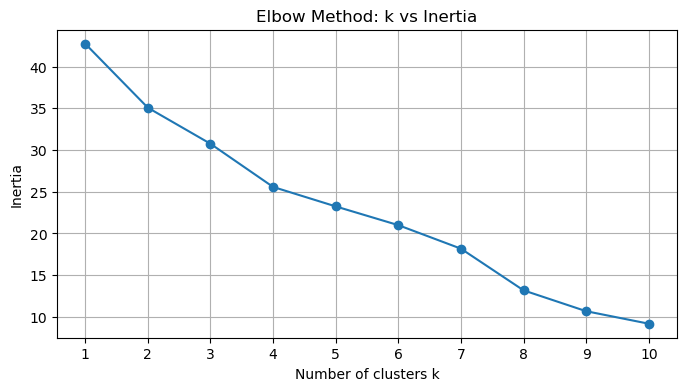

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


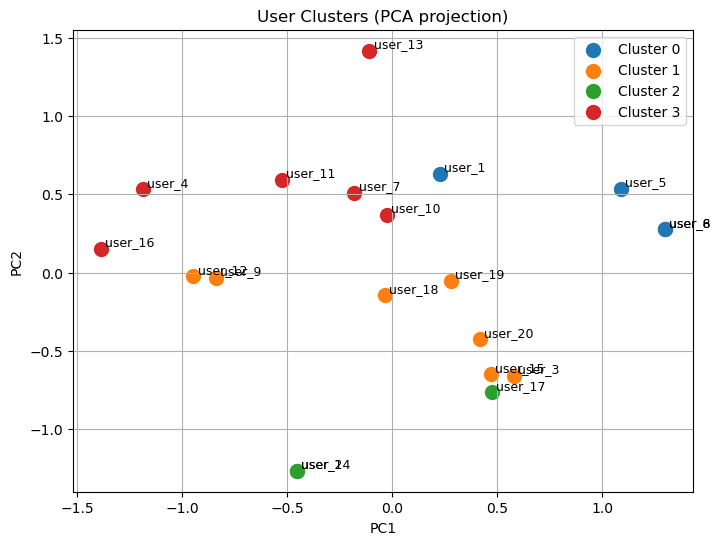

레터 보낼 사람: user_8
[user_8]가 레터를 보낼 사람: ['user_1', 'user_5', 'user_6']


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 1) 데이터 로드
user_tags = pd.read_csv("./user_tags.csv", index_col="user_id")

# 2) 엘보우 기법으로 최적의 클러스터 수 찾기
inertias = []
K_RANGE = range(1, 11)
X = user_tags.values

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_RANGE, inertias, marker='o')
plt.title("Elbow Method: k vs Inertia")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.xticks(K_RANGE)
plt.grid(True)
plt.show()

# 3) 선택한 k로 KMeans 학습 (예: k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42).fit(X)
user_tags['cluster'] = kmeans.labels_

# 4) PCA로 2차원으로 투영해 시각화
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for cluster_id in range(optimal_k):
    mask = user_tags['cluster'] == cluster_id
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f"Cluster {cluster_id}", s=100)
    for uid, (x, y) in zip(user_tags.index[mask], coords[mask]):
        plt.text(x + 0.02, y + 0.02, uid, fontsize=9)
plt.title("User Clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

# 5) 코사인 유사도 매트릭스
sim_matrix = pd.DataFrame(cosine_similarity(X), index=user_tags.index, columns=user_tags.index)

# 6) 하이브리드 수신자 선정 함수
def pick_receivers_hybrid(user_id, top_k=5):
    if user_id not in user_tags.index:
        raise ValueError(f"Unknown user_id: {user_id}")
    my_cluster = user_tags.at[user_id, 'cluster']
    members = user_tags[user_tags['cluster'] == my_cluster].index.drop(user_id).tolist()
    if len(members) >= top_k:
        sims = sim_matrix.loc[user_id, members]
        return sims.nlargest(top_k).index.tolist()
    else:
        return members

# 7) 예시
example_user = input("레터 보낼 사람: ")
receivers = pick_receivers_hybrid(example_user, top_k=5)
print(f"[{example_user}]가 레터를 보낼 사람:", receivers)


In [4]:
import pandas as pd

# Generate synthetic user_tags (5 users x 10 tags)
user_ids = [f"user_{i}" for i in range(1,6)]
tags = ["음악", "미식", "야간", "액티비티", "포토", "힐링", "역사", "예술", "가족", "커플"]
import numpy as np
np.random.seed(0)

user_tags = pd.DataFrame({
    "user_id": np.repeat(user_ids, len(tags)),
    "tag": tags * len(user_ids),
    "score": np.random.randint(0, 2, size=len(user_ids)*len(tags))  # 0 or 1 indicate interest
})
user_tags.to_csv("./data/user_tags.csv", index=False)

# Generate synthetic festival_tags (5 festivals x 10 tags)
festival_ids = [f"fest_{i}" for i in range(1,6)]
festival_tags = pd.DataFrame({
    "festival_id": np.repeat(festival_ids, len(tags)),
    "tag": tags * len(festival_ids),
    "score": np.random.randint(0, 2, size=len(festival_ids)*len(tags))
})
festival_tags.to_csv("./data/festival_tags.csv", index=False)

# Generate synthetic user-festival interactions (behavior)
behavior = pd.DataFrame({
    "user_id": np.random.choice(user_ids, 20),
    "festival_id": np.random.choice(festival_ids, 20),
    "action": np.random.choice(["click", "like", "visit"], 20)
})
behavior.to_csv("./data/behavior.csv", index=False)

# Generate synthetic social edges among users
edges = pd.DataFrame({
    "from_user": np.random.choice(user_ids, 10),
    "to_user": np.random.choice(user_ids, 10)
})
edges = edges[edges.from_user != edges.to_user]
edges.to_csv("./data/edges.csv", index=False)

# Display to user
from ace_tools import display_dataframe_to_user
display_dataframe_to_user("user_tags.csv", user_tags)
display_dataframe_to_user("festival_tags.csv", festival_tags)
display_dataframe_to_user("behavior.csv", behavior)
display_dataframe_to_user("edges.csv", edges)


ModuleNotFoundError: No module named 'ace_tools'

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1) 예시 사용자 가중치 벡터 생성 (Dirichlet)
np.random.seed(42)
user_ids = [f"user_{i:02d}" for i in range(1,21)]
alpha = np.ones(10)  # 균일 사전 기대치
user_weights = np.random.dirichlet(alpha, size=len(user_ids))
df_users = pd.DataFrame(user_weights, index=user_ids,
                        columns=[f"tag_{i}" for i in range(1,11)])

# 2) 예시 축제 태그 분포 (간단 랜덤)
fest_ids = ["fest_01","fest_02","fest_03"]
fest_weights = np.random.dirichlet(alpha, size=len(fest_ids))
df_fests = pd.DataFrame(fest_weights, index=fest_ids,
                        columns=df_users.columns)

# 3) 특정 사용자→축제 적합도 계산
def fit_pct(user_id, fest_id):
    u = df_users.loc[user_id].values.reshape(1,-1)
    f = df_fests.loc[fest_id].values.reshape(1,-1)
    sim = cosine_similarity(u,f)[0,0]
    return round(sim*100,1)

# 4) 테스트: user_01에게 각 축제 적합도
for fest in fest_ids:
    print(f"{fest} 적합도 → {fit_pct('user_01', fest)}%")


fest_01 적합도 → 45.4%
fest_02 적합도 → 81.7%
fest_03 적합도 → 41.2%


In [25]:
fest_weights

array([[0.1741792 , 0.01490193, 0.02989046, 0.38796652, 0.15810314,
        0.00156656, 0.01814119, 0.18466607, 0.00086036, 0.02972457],
       [0.08371037, 0.12385794, 0.11103636, 0.02671647, 0.13102252,
        0.02849167, 0.04141185, 0.14437711, 0.1103349 , 0.19904081],
       [0.1031425 , 0.08083896, 0.00946507, 0.04411422, 0.0296548 ,
        0.02691605, 0.34761895, 0.04805695, 0.21421725, 0.09597526]])

# 사용자 태그 벡터 업데이트 과정 코드

In [43]:
import pandas as pd
import numpy as np

# 파일 경로
COUNTS_CSV = './user_counts.csv'
VECTORS_CSV = './user_vectors.csv'
FESTIVAL_TAGS_CSV = './Festival_Tags.csv'

# 1) 데이터 로드
counts_df = pd.read_csv(COUNTS_CSV, index_col='user_id')
vectors_df = pd.read_csv(VECTORS_CSV, index_col='user_id')
fest_tags_df = pd.read_csv(FESTIVAL_TAGS_CSV, index_col='fest_id')

# 2) UserProfile 클래스 정의
class UserProfile:
    def __init__(self, user_id, counts_df, vectors_df):
        self.user_id = user_id
        # counts: pandas Series
        self.counts = counts_df.loc[user_id].astype(float)
        # vec: pandas Series
        self.vec = vectors_df.loc[user_id].astype(float)
        # 총 카운트
        self.N = self.counts.sum()

    def like_festival(self, fest_vec):
        # fest_vec: pandas Series of 0/1 for tags
        # counts에 축제 태그만큼 증가
        self.counts += fest_vec
        # 총 카운트 증가
        self.N += fest_vec.sum()
        # 벡터 재정규화
        self.vec = self.counts / self.N

    def to_series(self):
        return self.vec

    def counts_series(self):
        return self.counts

# 3) 사용자 입력
print("사용 가능한 사용자:", list(counts_df.index))
print("사용 가능한 축제 IDs:", list(fest_tags_df.index))
user_id = input("사용자 ID를 입력하세요: ")
fest_id = input("좋아요를 누른 축제 ID를 입력하세요: ")

# 4) 프로필 업데이트
if user_id not in counts_df.index:
    raise ValueError(f"Unknown user_id: {user_id}")
if fest_id not in fest_tags_df.index:
    raise ValueError(f"Unknown fest_id: {fest_id}")

# 축제 태그 벡터 로드
fest_vec = fest_tags_df.loc[fest_id].astype(int)

# UserProfile 생성 및 업데이트
profile = UserProfile(user_id, counts_df, vectors_df)
profile.like_festival(fest_vec)

# 5) DataFrame에 반영 및 저장
# counts 데이터 업데이트
counts_df.loc[user_id] = profile.counts
# vectors 데이터 업데이트 (float)
vectors_df.loc[user_id] = profile.vec

# 파일로 저장
counts_df.to_csv(COUNTS_CSV)
vectors_df.to_csv(VECTORS_CSV)

print(f"사용자 {user_id} 프로필이 업데이트되었습니다.")
print("새 counts:")
print(profile.counts)
print("새 vector:")
print(profile.vec)


사용 가능한 사용자: ['user_01', 'user_02', 'user_03', 'user_04', 'user_05', 'user_06', 'user_07', 'user_08', 'user_09', 'user_10', 'user_11', 'user_12', 'user_13', 'user_14', 'user_15', 'user_16', 'user_17', 'user_18', 'user_19', 'user_20']
사용 가능한 축제 IDs: ['fest_01', 'fest_02', 'fest_03', 'fest_04', 'fest_05', 'fest_06', 'fest_07', 'fest_08', 'fest_09', 'fest_10', 'fest_11', 'fest_12', 'fest_13', 'fest_14', 'fest_15', 'fest_16', 'fest_17', 'fest_18', 'fest_19', 'fest_20']
사용자 ID를 입력하세요: user_07
좋아요를 누른 축제 ID를 입력하세요: fest_05
사용자 user_07 프로필이 업데이트되었습니다.
새 counts:
tag_1     3.0
tag_2     5.0
tag_3     3.0
tag_4     5.0
tag_5     0.0
tag_6     3.0
tag_7     2.0
tag_8     3.0
tag_9     2.0
tag_10    6.0
N         NaN
Name: user_07, dtype: float64
새 vector:
tag_1     0.050847
tag_2     0.084746
tag_3     0.050847
tag_4     0.084746
tag_5     0.000000
tag_6     0.050847
tag_7     0.033898
tag_8     0.050847
tag_9     0.033898
tag_10    0.101695
N              NaN
Name: user_07, dtype: float64


# 레터 보낼 사용자 선정 모델

In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ——————————————
# 1) 데이터 로드
# ——————————————
# users: 각 user_id별 태그 선호 벡터 (합 = 1)
# fests: 각 fest_id별 태그 원핫 벡터 (0/1)
users = pd.read_csv("./user_vectors.csv", index_col="user_id")
fests = pd.read_csv("./Festival_Tags.csv", index_col="fest_id")

# 1.1) 사용자 간 유사도 매트릭스 미리 계산 (협업 유사도용)
user_sim_matrix = pd.DataFrame(
    cosine_similarity(users.values),
    index=users.index,
    columns=users.index
)


# ——————————————
# 2) 적합도(%) 계산 함수
# ——————————————
def compute_scores(sender_id: str, fest_id: str, alpha: float = 0.3):
    """
    sender_id 가 fest_id 축제를 추천했을 때,
    모든 다른 사용자에 대해
      - sim_c = 콘텐츠(태그) 유사도
      - sim_u = 사용자-사용자 협업 유사도
    를 계산하고, α·sim_c + (1-α)·sim_u 으로
    최종 스코어를 리턴합니다.
    """
    # 2.1) 벡터 꺼내오기
    u_vec = users.loc[sender_id].values.reshape(1, -1)
    f_vec = fests.loc[fest_id].values.reshape(1, -1)

    # 2.2) 콘텐츠 유사도 (User↔Festival)
    sim_c = cosine_similarity(u_vec, f_vec)[0, 0]

    # 2.3) 협업 유사도 (User↔All Users)
    sim_u_series = user_sim_matrix.loc[sender_id]

    # 2.4) 가중 결합
    final_scores = alpha * sim_c + (1 - alpha) * sim_u_series

    # 2.5) DataFrame 형태로 리턴
    return pd.DataFrame({
        "sim_c": sim_c,
        "sim_u": sim_u_series,
        "score": final_scores
    })


# ——————————————
# 3) 레터 수신자 추천 함수
# ——————————————
def pick_receivers(sender_id: str,
                   fest_id: str,
                   alpha: float = 0.3,
                   top_k: int = 4):
    """
    sender_id 가 fest_id 축제를 추천할 때,
    최종 스코어 상위 top_k 명을 뽑고,
    sim_c, sim_u, 최종 score 모두 %로 변환해 리턴.
    """
    # 3.1) 스코어 계산
    df = compute_scores(sender_id, fest_id, alpha)

    # 3.2) 자기 자신 제외
    df = df.drop(index=sender_id, errors="ignore")

    # 3.3) 상위 K명 뽑기
    top = df.sort_values("score", ascending=False).head(top_k)

    # 3.4) % 환산
    top["sim_c_pct"]  = (top["sim_c"]  * 100).round(1)
    top["sim_u_pct"]  = (top["sim_u"]  * 100).round(1)
    top["final_pct"]  = (top["score"]  * 100).round(1)

    return top[["sim_c_pct", "sim_u_pct", "final_pct"]]


# ——————————————
# 4) 실행 예시
# ——————————————
if __name__ == "__main__":
    sender = input("▶ 추천 발송자 기준 유저(user_id): ")
    fest   = input("▶ 추천할 축제(fest_id): ")
    alpha  = float(0.3)

    recs = pick_receivers(sender, fest, alpha=alpha, top_k=4)

    print(f"\n🎯 [{sender}] → 축제[{fest}] 레터 수신자 TOP4 (α={alpha})\n")
    for uid, row in recs.iterrows():
        print(f" - {uid}: 축제매칭 {row.sim_c_pct}%  |  태그유사 {row.sim_u_pct}%  →  최종 {row.final_pct}%")


▶ 추천 발송자 기준 유저(user_id): user_07
▶ 추천할 축제(fest_id): fest_08

🎯 [user_07] → 축제[fest_08] 레터 수신자 TOP4 (α=0.3)

 - user_01: 축제매칭 44.9%  |  태그유사 86.9%  →  최종 74.3%
 - user_12: 축제매칭 44.9%  |  태그유사 86.4%  →  최종 73.9%
 - user_16: 축제매칭 44.9%  |  태그유사 84.8%  →  최종 72.8%
 - user_20: 축제매칭 44.9%  |  태그유사 84.6%  →  최종 72.7%


In [48]:
import pandas as pd
import numpy as np

# 사용자 20명, 축제 20개 정의
user_ids = [f"user_{i:02d}" for i in range(1, 21)]
fest_ids = [f"fest_{i:02d}" for i in range(1, 21)]

np.random.seed(42)
records = []
for sender in user_ids:
    # sender당 5개 축제 선택
    chosen_fests = np.random.choice(fest_ids, size=5, replace=False)
    for fest in chosen_fests:
        # 각 축제마다 5명 recipient
        recipients = np.random.choice([u for u in user_ids if u != sender], size=50, replace=True)
        for rec in recipients:
            clicked = np.random.choice([0, 1], p=[0.6, 0.4])  # 40% 클릭 확률
            records.append({
                "sender_id": sender,
                "recipient_id": rec,
                "fest_id": fest,
                "clicked": clicked
            })

interactions = pd.DataFrame(records)
interactions.to_csv("./interactions.csv", index=False, encoding="utf-8-sig")

# 미리보기
print(interactions.head())


  sender_id recipient_id  fest_id  clicked
0   user_01      user_03  fest_01        1
1   user_01      user_02  fest_01        1
2   user_01      user_13  fest_01        0
3   user_01      user_13  fest_01        0
4   user_01      user_18  fest_01        1


In [49]:
import pandas as pd

# 1) 기존 인터랙션 불러오기
interactions = pd.read_csv("./interactions.csv")

# 2) 무작위 50건 샘플링
sample50 = interactions.sample(n=50, random_state=42)

# 3) 파일로 저장
sample50.to_csv("./interactions_50.csv", index=False, encoding="utf-8-sig")

# 4) 확인
print(sample50.head())
print(f"\n샘플링된 레코드 수: {len(sample50)}")


     sender_id recipient_id  fest_id  clicked
1501   user_07      user_16  fest_10        1
2586   user_11      user_18  fest_16        1
2653   user_11      user_13  fest_04        1
1055   user_05      user_16  fest_01        0
705    user_03      user_19  fest_05        0

샘플링된 레코드 수: 50


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1) 데이터 로드
#    - users: user_vectors.csv (index: user_id, columns: tag_1…tag_10, 합=1)
#    - fests: Festival_Tags.csv (index: fest_id, columns: tag_1…tag_10, 0/1)
#    - inter: interactions.csv (sender_id, recipient_id, fest_id, clicked(0/1))
users = pd.read_csv("./user_vectors.csv", index_col="user_id")
fests = pd.read_csv("./Festival_Tags.csv", index_col="fest_id")
inter = pd.read_csv("./interactions.csv")
inter["clicked"] = inter["clicked"].astype(int)

# 2) 유사도 행렬 계산
user_sim = cosine_similarity(users.values)                       # (n_users×n_users)
fest_sim = cosine_similarity(users.values, fests.values)        # (n_users×n_fests)

# 3) 학습용 피처 생성 함수
def make_features(df):
    df = df.copy()
    # sender↔recipient 유사도
    df["sim_u"] = df.apply(
        lambda r: user_sim[
            users.index.get_loc(r.sender_id),
            users.index.get_loc(r.recipient_id)
        ],
        axis=1
    )
    # recipient↔fest 콘텐츠 유사도
    df["sim_c"] = df.apply(
        lambda r: fest_sim[
            users.index.get_loc(r.recipient_id),
            fests.index.get_loc(r.fest_id)
        ],
        axis=1
    )
    return df

data = make_features(inter)

# 4) 피처 스케일링 (0~1)
scaler = MinMaxScaler()
X = scaler.fit_transform(data[["sim_c", "sim_u"]])
y = data["clicked"].values

# 5) 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6) 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 7) 성능 평가 (AUC)
probs = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)
print(f"▶ Test AUC: {auc:.3f}")

# 8) 실시간 추천 함수
def recommend_recipients(sender_id, fest_id, top_k=4):
    # 후보 수신자 (self 제외)
    cands = [u for u in users.index if u != sender_id]
    feats = []
    for u in cands:
        sim_u = user_sim[users.index.get_loc(sender_id),
                         users.index.get_loc(u)]
        sim_c = fest_sim[users.index.get_loc(u),
                         fests.index.get_loc(fest_id)]
        feats.append([sim_c, sim_u])
    feats = np.array(feats)
    feats = scaler.transform(feats)
    scores = model.predict_proba(feats)[:,1]
    # 상위 K명
    idx = np.argsort(scores)[-top_k:][::-1]
    return pd.DataFrame({
        "recipient": [cands[i] for i in idx],
        "match_pct": (scores[idx]*100).round(1)
    })

# 9) 사용 예시
if __name__ == "__main__":
    sender = input("▶ sender user_id: ")
    fest   = input("▶ fest_id: ")
    print("\n💌 추천 TOP4 수신자:")
    print(recommend_recipients(sender, fest, top_k=4))


▶ Test AUC: 0.470
▶ sender user_id: user_08
▶ fest_id: fest_16

💌 추천 TOP4 수신자:
  recipient  match_pct
0   user_03       39.4
1   user_11       38.6
2   user_16       38.1
3   user_01       38.1


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [5]:
data

,sender_id,recipient_id,fest_id,clicked,sim_u,sim_c
0,user_01,user_03,fest_01,1,0.707107,0.322749
1,user_01,user_02,fest_01,1,0.795147,0.207390
2,user_01,user_13,fest_01,0,0.651727,0.246183
3,user_01,user_13,fest_01,0,0.651727,0.246183
4,user_01,user_18,fest_01,1,0.774463,0.558146
...,...,...,...,...,...,...
4995,user_20,user_05,fest_04,1,0.735544,0.465778
4996,user_20,user_16,fest_04,0,0.732903,0.614940
4997,user_20,user_07,fest_04,0,0.860151,0.509902
4998,user_20,user_19,fest_04,1,0.818691,0.460739


# 축제 overview를 토대로 태그 붙이는 모델

In [8]:
import pandas as pd
import numpy as np
import re, string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1) 데이터 로드
df = pd.read_csv('./festivals_full_details.csv')
texts = (df['title'].fillna('') + ' ' + df['overview'].fillna('')).tolist()

# 2) 간단 클린
def clean(t): 
    t = t.lower()
    t = re.sub(r'\d', ' ', t)
    return t.translate(str.maketrans('', '', string.punctuation))
corpus = [clean(t) for t in texts]

# 3) TF-IDF
vec = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
X   = vec.fit_transform(corpus)

# 4) K-Means
k = 50              # ← elbow/silhouette로 조정
km = KMeans(n_clusters=k, random_state=42).fit(X)
df['cluster'] = km.labels_

# 5) 군집 키워드
terms = np.array(vec.get_feature_names_out())
def top_words(c, n=12):
    center = km.cluster_centers_[c]
    return ', '.join(terms[center.argsort()[-n:][::-1]])
summaries = [
    (c, (df['cluster']==c).sum(), top_words(c)) for c in range(k)
]
summary_df = pd.DataFrame(summaries, columns=['cluster','size','keywords'])
summary_df.head(10)


,cluster,size,keywords
0,0,3,"싱싱한, 자연산, 도다리, 무창포, 도미, 광어, 자연산 광어, 광어 도미, 완도군..."
1,1,21,"어린이, 다양한, 맞아, 어린이날을, 위한, 체험, 추억을 만들, 만들, 어린이날을..."
2,2,14,"있다, 있는, 통해, 준비되어, 또한, 다양한, 코리아그랜드세일, 이월드, 상품을,..."
3,3,49,"특별한, 있는, 있다, 함께, 추억을, 즐길, 즐길 있는, 통해, 다양한, 잊지, ..."
4,4,8,"남한산성, 과학, 기술을, 로봇, 파주출판도시, 체험, 다양한, 선사한다, 세계유산..."
5,5,14,"댄스, 스트리트, 공연, 넥스트, 여름을, 동터, 주제로 다양한, 문화, 즐길 있는..."
6,6,9,"지역, 동두천, 방화수류정은, 세계인, 울산, 주최하고, 옥정호, 마련한, 골프, ..."
7,7,28,"누구나, 누구나 즐길, 등이, 즐길, 있는, 남녀노소 누구나, 남녀노소, 즐길 있는..."
8,8,4,"경상북도의, 원동면, 미나리, 경북, 해를, 와일드오차드, 유기농, 해넘이해맞이축제..."
9,9,13,"공주, 수라간, 주제로, 직접, 준비되어, 딸기를, 유구, 색동수국정원, 유구 색동..."


In [9]:
summary_df.to_csv('./Festival_tags_tf_idf.csv')

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1) 데이터 로드
file_path = "./festivals_full_details.csv"
df = pd.read_csv(file_path)

# 2) overview 전처리 (결측치 제거)
overviews = df['overview'].dropna()

# 3) TF‑IDF 벡터라이징
vectorizer = TfidfVectorizer(max_df=0.5, min_df=2, ngram_range=(1, 2), token_pattern=r'(?u)\b\w+\b')
X = vectorizer.fit_transform(overviews)

# 4) K‑Means 군집화: 50개 클러스터  → 각 클러스터당 minor 태그 5개씩 ≒ 250개
n_clusters = 50
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km.fit(X)

terms = vectorizer.get_feature_names_out()

# 5) 클러스터별 상위 키워드 추출 → 대·중·소 태그 정의
cluster_details = []
for i in range(n_clusters):
    center = km.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]          # 중심 벡터 기준 상위 10개 단어
    top_terms = [terms[idx] for idx in top_idx]

    major = top_terms[0]            # 대분류 대표
    middle = top_terms[1:3]         # 중분류(2개)
    minor = top_terms[3:8]          # 소분류(5개)
    cluster_size = (km.labels_ == i).sum()

    cluster_details.append({
        "대분류(Cluster)": f"Cluster_{i}",
        "대표태그(대)": major,
        "중분류 태그(2)": ", ".join(middle),
        "소분류 태그(5)": ", ".join(minor),
        "소속 축제 수": cluster_size
    })

tag_df = pd.DataFrame(cluster_details).sort_values("대표태그(대)")

# 6) CSV 저장
output_path = "./generated_tag_hierarchy.csv"
tag_df.to_csv(output_path, index=False)

# ChatGPT 환경에서만 동작하는 부분 → 로컬에서는 패스
try:
    import ace_tools as tools
    tools.display_dataframe_to_user("대-중-소 태그 체계 (미리보기)", tag_df.head(20))
except ModuleNotFoundError:
    # 대체 출력 방법
    print(tag_df.head(20))
    print("\n※ 로컬 환경에는 'ace_tools' 모듈이 없으므로 표 대신 콘솔에 미리보기만 표시했습니다.")

print(f"태그 요약 테이블이 '{output_path}' 에 저장되었습니다.")

ModuleNotFoundError: No module named 'ace_tools'

In [6]:
"""
태그 추출·매핑 파이프라인 (overview 열 기준)
================================================
⚙️  필요 라이브러리
------------------------------------------------
$ pip install pandas sentence-transformers keybert scikit-learn pyyaml tqdm

▶️ 사용법
------------------------------------------------
python tag_pipeline.py --csv festivals_full_details.csv --yaml tag_dictionary.yml --out_dir outputs/

- --csv : overview 컬럼이 포함된 원본 CSV 경로
- --yaml: (대분류→중분류 사전) YAML 파일 경로
- --out_dir : 결과 CSV 저장 폴더 (기본: ./outputs)

산출물
------------------------------------------------
1. raw_tag_list.csv   – (tag, doc_id, freq)
2. clean_tags.csv     – (tag, category, freq)

※ Sentence-BERT 모델은 paraphrase-multilingual-MiniLM-L12-v2 (384‑dim)
"""

import argparse
import os
import re
import yaml
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
from sentence_transformers import SentenceTransformer
from keybert import KeyBERT
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

tqdm.pandas()

# -----------------------------------------------------------------------------
# 1. 전처리 함수
# -----------------------------------------------------------------------------

def clean_text(text: str) -> str:
    """HTML·특수문자 제거 + 다중 공백 정리"""
    if pd.isna(text):
        return ""
    text = re.sub(r"<[^>]+>", " ", str(text))  # HTML tag
    text = re.sub(r"[^\w\s가-힣]", " ", text)  # 특수문자
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

# -----------------------------------------------------------------------------
# 2. 키워드 추출 (KeyBERT)
# -----------------------------------------------------------------------------

def extract_keywords(text: str, kb_model: KeyBERT, top_n: int = 20):
    """top_n 키워드(1~3gram) 리스트 반환"""
    kw = kb_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3),
        stop_words="korean",
        top_n=top_n,
    )
    return [k for k, _ in kw]

# -----------------------------------------------------------------------------
# 3. 태그 사전 로드 & 벡터화
# -----------------------------------------------------------------------------

def load_tag_dict(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        tag_dict = yaml.safe_load(f)
    flat_terms, cat_of = [], []
    for cat, terms in tag_dict.items():
        flat_terms.extend(terms)
        cat_of.extend([cat] * len(terms))
    return tag_dict, flat_terms, cat_of

# -----------------------------------------------------------------------------
# 4. 태그 매핑 함수
# -----------------------------------------------------------------------------

def build_semantic_mapper(model, flat_terms, cat_of, threshold: float = 0.65):
    """입력 태그 → 카테고리 문자열 반환 (임계값 미달 시 None)"""
    term_vecs = model.encode(flat_terms, batch_size=64, show_progress_bar=False)

    def mapper(tag: str):
        vec = model.encode([tag])[0]
        sims = cosine_similarity([vec], term_vecs)[0]
        idx = sims.argmax()
        return cat_of[idx] if sims[idx] >= threshold else None

    return mapper

# -----------------------------------------------------------------------------
# 5. 메인 파이프라인
# -----------------------------------------------------------------------------

def pipeline(csv_path: Path, yaml_path: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)

    # ① 데이터 로드 & 전처리
    df = pd.read_csv(csv_path)
    df["doc_clean"] = (df["title"].fillna("") + " " + df["overview"].fillna(""))
    df["doc_clean"] = df["doc_clean"].apply(clean_text)

    # ② 모델 준비
    sbert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    kb_model = KeyBERT(model=sbert_model)

    # ③ 키워드 추출
    df["keywords"] = df["doc_clean"].progress_apply(lambda x: extract_keywords(x, kb_model))

    # ④ 키워드 집계 (빈도 필터)
    all_tags = [kw for kws in df["keywords"] for kw in kws]
    freq = Counter(all_tags)
    tag_freq = {t: c for t, c in freq.items() if c >= 3}  # min freq=3

    # ⑤ 태그 사전 로드 & 매퍼 생성
    tag_dict, flat_terms, cat_of = load_tag_dict(yaml_path)
    mapper = build_semantic_mapper(sbert_model, flat_terms, cat_of)

    # ⑥ 매핑 수행 & 결과 저장
    raw_rows, clean_rows = [], []
    for doc_id, kws in enumerate(df["keywords"]):
        for kw in kws:
            if kw not in tag_freq:
                continue
            raw_rows.append({"tag": kw, "doc_id": doc_id})
    raw_df = pd.DataFrame(raw_rows)
    raw_df = raw_df.groupby("tag").agg(freq=("doc_id", "nunique")).reset_index()
    raw_df.to_csv(out_dir / "raw_tag_list.csv", index=False)

    for tag, f in tag_freq.items():
        cat = mapper(tag)
        if cat:
            clean_rows.append({"tag": tag, "category": cat, "freq": f})
    clean_df = (
        pd.DataFrame(clean_rows)
        .sort_values(["category", "freq"], ascending=[True, False])
    )
    clean_df.to_csv(out_dir / "clean_tags.csv", index=False)

    print(f"[완료] raw_tag_list.csv & clean_tags.csv 저장 → {out_dir.resolve()}")

# -----------------------------------------------------------------------------
# Entry Point
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Festival Tag Pipeline")
    parser.add_argument("--csv", required=True, help="원본 CSV 경로")
    parser.add_argument("--yaml", required=True, help="태그 사전 YAML 경로")
    parser.add_argument("--out_dir", default="outputs", help="결과 저장 폴더")
    args = parser.parse_args()

    pipeline(Path(args.csv), Path(args.yaml), Path(args.out_dir))


usage: ipykernel_launcher.py [-h] --csv CSV --yaml YAML [--out_dir OUT_DIR]
ipykernel_launcher.py: error: the following arguments are required: --csv, --yaml


SystemExit: 2

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\IPython\core\interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
from pathlib import Path

csv_path  = Path(r"./festivals_full_details.csv")
yaml_path = Path(r"./tag_dictionary.yml")
out_dir   = Path(r"./outputs")

pipeline(csv_path, yaml_path, out_dir)

100%|██████████████████████████████████████████████████████████████████████████████| 781/781 [00:00<00:00, 8064.66it/s]


ScannerError: mapping values are not allowed here
  in "tag_dictionary.yml", line 5, column 7

# 사용자 축제 적합도 출력 모델

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
import pickle

# ─── 1. 데이터 로드 ───────────────────────────────────────────────
user_df = pd.read_csv('./user_vectors.csv', index_col='user_id')
fest_df = pd.read_csv('./Festival_Tags.csv', index_col='fest_id')

# ─── 2. 태그 칼럼 추출 & 검증 ───────────────────────────────────────
tag_cols = [c for c in user_df.columns if c.startswith('tag_')]
assert tag_cols == [c for c in fest_df.columns if c.startswith('tag_')], \
    "태그 칼럼 순서가 일치하지 않습니다."

# ─── 3. 데모 상호작용(interactions) 생성 ───────────────────────────
# 시연을 위해 user_01 의 일부 축제에 대해 'like', 'click', 'view' 이벤트 할당
demo_fests = fest_df.index.tolist()
actions = ['like'] * 2 + ['click'] * 3 + ['view'] * (len(demo_fests) - 5)
interactions = pd.DataFrame({
    'user_id': ['user_01'] * len(demo_fests),
    'fest_id': demo_fests,
    'action': actions
})

# ─── 4. 이벤트별 가중치 매핑 ───────────────────────────────────────
action_weights = {'view': 0.2, 'click': 0.5, 'like': 1.0}

# ─── 5. 학습용 데이터(X, y, sample_weight) 구성 ─────────────────────
X_train, y_train, w_train = [], [], []
for _, row in interactions.iterrows():
    u = user_df.loc[row['user_id'], tag_cols].values.astype(float)
    v = fest_df.loc[row['fest_id'], tag_cols].values.astype(float)
    X_train.append(u * v)  # Hadamard(요소곱)
    y_train.append(1 if row['action'] in ('click', 'like') else 0)
    w_train.append(action_weights[row['action']])

X_train = np.vstack(X_train)
y_train = np.array(y_train)
w_train = np.array(w_train)

# ─── 6. Logistic Regression 학습 ───────────────────────────────────
clf = SGDClassifier(
    loss='log_loss', 
    penalty='l2', 
    alpha=1e-4, 
    class_weight='balanced', 
    max_iter=1000, 
    tol=1e-3
)
clf.fit(X_train, y_train, sample_weight=w_train)

# 모델 저장
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(clf, f)

# ─── 7. 추천 함수 정의 ─────────────────────────────────────────────
def recommend(user_id, top_n=5):
    if user_id not in user_df.index:
        raise KeyError(f"'{user_id}' 사용자를 찾을 수 없습니다.")
    u = user_df.loc[user_id, tag_cols].values.astype(float)
    V = fest_df[tag_cols].values.astype(float)
    X_feat = u * V
    probs = clf.predict_proba(X_feat)[:, 1]
    
    top_idx = np.argsort(probs)[::-1][:top_n]
    recs = fest_df.iloc[top_idx].copy()
    recs['score'] = [f"{p*100:.2f}%" for p in probs[top_idx]]
    return recs[['score']]

# ─── 8. 시연: user_01 추천 결과 ─────────────────────────────────
print("=== user_01 추천 결과 ===")
print(recommend('user_01', top_n=5))

=== user_01 추천 결과 ===
          score
fest_id        
fest_02  93.83%
fest_04  93.11%
fest_16  92.85%
fest_03  92.83%
fest_09  91.46%


In [15]:
user_df = pd.read_csv('./user_vectors.csv', index_col='user_id')
fest_df = pd.read_csv('./Festival_Tags.csv', index_col='fest_id')

# ─── 2. 태그 칼럼 추출 & 검증 ───────────────────────────────────────
tag_cols = [c for c in user_df.columns if c.startswith('tag_')]
assert tag_cols == [c for c in fest_df.columns if c.startswith('tag_')], \
    "태그 칼럼 순서가 일치하지 않습니다."

# ─── 3. 데모 상호작용(interactions) 생성 ───────────────────────────
# 시연을 위해 user_01 의 일부 축제에 대해 'like', 'click', 'view' 이벤트 할당
demo_fests = fest_df.index.tolist()
actions = ['like'] * 2 + ['click'] * 3 + ['view'] * (len(demo_fests) - 5)
interactions = pd.DataFrame({
    'user_id': ['user_01'] * len(demo_fests),
    'fest_id': demo_fests,
    'action': actions
})

interactions

,user_id,fest_id,action
0,user_01,fest_01,like
1,user_01,fest_02,like
2,user_01,fest_03,click
3,user_01,fest_04,click
4,user_01,fest_05,click
5,user_01,fest_06,view
6,user_01,fest_07,view
7,user_01,fest_08,view
8,user_01,fest_09,view
9,user_01,fest_10,view


In [37]:
# =============================================
# 축제 추천 – Soft-Match 벡터 버전 (Jupyter 셀)
# =============================================
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import SGDClassifier

# ─── 1. 파일 경로 지정 ─────────────────────────
USER_VEC_CSV  = Path("./Randomized_User_Vectors__Sample_.csv")                   # 무작위 또는 기존 사용자 벡터 (sub-tags)
FEST_VEC_CSV  = Path("./festivals_sub_softmatch_vectors.csv")    # Soft-Match 소분류 TF-IDF 벡터
INTERACT_CSV  = Path("./interactions.csv")                         # 이벤트 로그

# ─── 2. 하이퍼파라미터 ────────────────────────
ACTION_WEIGHTS   = {"view": 0.2, "click": 0.5, "like": 1.0}
POSITIVE_ACTIONS = {"click", "like"}
TOP_N            = 5                                              # 추천 개수

# ─── 3. 데이터 로드 ───────────────────────────
user_df = pd.read_csv(USER_VEC_CSV, index_col="user_id")
fest_df = pd.read_csv(FEST_VEC_CSV, index_col="index")
inter   = pd.read_csv(INTERACT_CSV) 

# ─── 4. 태그(벡터) 칼럼 추출 ────────────────────
# 이제 user_df와 fest_df가 동일한 sub-tag 컬럼을 가져야 합니다
tag_cols = user_df.columns.tolist()
assert set(tag_cols) == set(fest_df.columns.tolist()), \
       "⚠️ user_df / fest_df 의 소분류 태그 컬럼 구성이 다릅니다."

# ─── 5. 학습 데이터 구성 ───────────────────────
X, y, w = [], [], []
for u_id, f_id, act in inter[["user_id", "fest_id", "action"]].itertuples(index=False):
    if u_id not in user_df.index or f_id not in fest_df.index:
        continue
    u_vec = user_df.loc[u_id, tag_cols].astype(float).values
    f_vec = fest_df.loc[f_id, tag_cols].astype(float).values
    X.append(u_vec * f_vec)                       # Hadamard product
    y.append(1 if act.lower() in POSITIVE_ACTIONS else 0)
    w.append(ACTION_WEIGHTS.get(act.lower(), 1.0))

# 반드시 샘플이 하나 이상 쌓였는지 체크
if not X:
    raise ValueError("상호작용 샘플(X)이 하나도 생성되지 않았습니다. interactions.csv를 확인하세요.")

X = np.vstack(X)
y = np.array(y)
w = np.array(w)

# ─── 6. 로지스틱 모델 학습 ────────────────────
clf = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    class_weight="balanced",
    max_iter=1000,
    tol=1e-3,
    random_state=42,
)
clf.fit(X, y, sample_weight=w)

# ─── 7. 추천 함수 ─────────────────────────────
def recommend(user_id: str, top_n: int = TOP_N) -> pd.DataFrame:
    """user_id 입력 → 상위 N개 축제와 확률 반환"""
    if user_id not in user_df.index:
        raise KeyError(f"'{user_id}' 사용자를 찾을 수 없습니다.")
    u_vec = user_df.loc[user_id, tag_cols].astype(float).values
    V     = fest_df[tag_cols].astype(float).values  # (N_fest, M_tags)
    feats = u_vec * V                               # broadcasting -> (N_fest, M_tags)
    probs = clf.predict_proba(feats)[:, 1]           # P(label=1)

    top_idx = np.argsort(probs)[::-1][:top_n]
    recs = fest_df.iloc[top_idx].copy()
    recs.insert(0, "probability", probs[top_idx])
    recs.reset_index(inplace=True)
    recs.rename(columns={"contentId": "fest_id"}, inplace=True)
    return recs[["fest_id", "probability"]]

# ─── 8. 사용 예시 ──────────────────────────────
print("=== user_01 추천 결과 ===")
print(recommend("user_01"))


AssertionError: ⚠️ user_df / fest_df 의 소분류 태그 컬럼 구성이 다릅니다.

In [24]:
from pathlib import Path
from recommend_engine import train, Recommender   # recommend_engine.py와 같은 폴더라면 import 가능

# 1) 학습 + 모델 저장
rec = train(
    Path("user_vectors.csv"),
    Path("all_festival_mid_tfidf_vectors_norm.csv"),
    Path("interactions.csv"),
    Path("lr_model.pkl")          # 저장 경로
)

# 2) 추천 사용
rec.recommend("user_01", top_n=5)


ModuleNotFoundError: No module named 'recommend_engine'

# festival에 tag 붙이는 코드

In [32]:
import pandas as pd
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# 1. 데이터 로드
tags_df = pd.read_csv('./all_tags_hierarchy.csv')
sub_tags = tags_df['소분류 (Tag)'].tolist()

festivals = pd.read_csv('./festivals_full_details.csv', dtype={'contentId': str})
docs = festivals['overview'].fillna('').tolist()
content_ids = festivals['contentId'].tolist()

# 2. 임베딩 모델 로드
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 3. 문서·태그 임베딩 계산
doc_embs = model.encode(docs, convert_to_numpy=True)      # (N, D)
tag_embs = model.encode(sub_tags, convert_to_numpy=True)  # (M, D)

# 4. 코사인 유사도 계산
doc_norm = doc_embs / np.linalg.norm(doc_embs, axis=1, keepdims=True)
tag_norm = tag_embs / np.linalg.norm(tag_embs, axis=1, keepdims=True)
cos_sim = np.matmul(doc_norm, tag_norm.T)                  # (N, M)

# 5. TF-IDF 벡터 생성
tfidf = TfidfVectorizer(vocabulary=sub_tags, lowercase=True, token_pattern=r"(?u)\b\w+\b")
tfidf_mat = tfidf.fit_transform(docs).toarray()            # (N, M)

# 6. Soft-Match 결합
alpha = 0.6
soft_features = alpha * tfidf_mat + (1 - alpha) * cos_sim  # (N, M)

# 7. L2 정규화
soft_norm = normalize(soft_features, norm='l2', axis=1)

# 8. DataFrame 생성 & 저장
df = pd.DataFrame(soft_norm, index=content_ids, columns=sub_tags)
df.reset_index().to_csv('festivals_sub_softmatch_vectors.csv', index=False, encoding='utf-8-sig')

# 9. 변환기·모델 저장
with open('tfidf_vect.pkl', 'wb') as f:   pickle.dump(tfidf, f)
with open('sbert_model.pkl', 'wb') as f:  pickle.dump(model, f)
with open('sub_tags.pkl', 'wb') as f:     pickle.dump(sub_tags, f)


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\feature_extraction\text.py:1368: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(
